In [1]:
%matplotlib inline

# Marginal Fitting: Businesses and Jobs (Global Level)

 * The total number of swiss-jobs must match the total number of active-swiss residents
 * The total number of swiss-fte must match the sum of of active-swiss residents

In [2]:
import logging
import os
import sys

from matplotlib import pyplot as plt
import pandas as pd
import geopandas as gpd

In [3]:
sys.path.append(r'\\Filer16L\P-V160L\SIMBA.A11244\90_Persoenlich\u229285\dev\SynPopToolbox')

In [4]:
from synpop import utils
from synpop.synpop import Persons, Businesses
from synpop.config import MSregion
from synpop.visualisations import save_figure

In [5]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)  # Set logging level: WARNING, INFO, DEBUG

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Settings" data-toc-modified-id="Settings-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Settings</a></span></li><li><span><a href="#Loading-Data" data-toc-modified-id="Loading-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Loading Data</a></span><ul class="toc-item"><li><span><a href="#SynPop" data-toc-modified-id="SynPop-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>SynPop</a></span><ul class="toc-item"><li><span><a href="#Scenario-Year" data-toc-modified-id="Scenario-Year-2.1.1"><span class="toc-item-num">2.1.1&nbsp;&nbsp;</span>Scenario-Year</a></span></li><li><span><a href="#Year-IST" data-toc-modified-id="Year-IST-2.1.2"><span class="toc-item-num">2.1.2&nbsp;&nbsp;</span>Year-IST</a></span></li></ul></li></ul></li><li><span><a href="#Exploring-Stats-per-Geographical-Areas" data-toc-modified-id="Exploring-Stats-per-Geographical-Areas-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Exploring Stats per Geographical Areas</a></span><ul class="toc-item"><li><span><a href="#Per-MS-Region" data-toc-modified-id="Per-MS-Region-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Per MS Region</a></span><ul class="toc-item"><li><span><a href="#Mapping-MS-Region-Mapping" data-toc-modified-id="Mapping-MS-Region-Mapping-3.1.1"><span class="toc-item-num">3.1.1&nbsp;&nbsp;</span>Mapping MS-Region Mapping</a></span></li><li><span><a href="#Computing-Stats" data-toc-modified-id="Computing-Stats-3.1.2"><span class="toc-item-num">3.1.2&nbsp;&nbsp;</span>Computing Stats</a></span></li></ul></li><li><span><a href="#Per-Arbeitsmarktregion" data-toc-modified-id="Per-Arbeitsmarktregion-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Per Arbeitsmarktregion</a></span><ul class="toc-item"><li><span><a href="#Mapping-to-Arbeitsmarktregion" data-toc-modified-id="Mapping-to-Arbeitsmarktregion-3.2.1"><span class="toc-item-num">3.2.1&nbsp;&nbsp;</span>Mapping to Arbeitsmarktregion</a></span></li><li><span><a href="#Computing-Stats" data-toc-modified-id="Computing-Stats-3.2.2"><span class="toc-item-num">3.2.2&nbsp;&nbsp;</span>Computing Stats</a></span></li></ul></li></ul></li><li><span><a href="#Scaling-up-swiss-jobs-to-match-number-of-employed-people" data-toc-modified-id="Scaling-up-swiss-jobs-to-match-number-of-employed-people-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Scaling up swiss jobs to match number of employed people</a></span><ul class="toc-item"><li><span><a href="#Scaling-Jobs-(CH-only)" data-toc-modified-id="Scaling-Jobs-(CH-only)-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Scaling Jobs (CH-only)</a></span></li><li><span><a href="#Checking-..." data-toc-modified-id="Checking-...-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Checking ...</a></span><ul class="toc-item"><li><span><a href="#New-Jobs" data-toc-modified-id="New-Jobs-4.2.1"><span class="toc-item-num">4.2.1&nbsp;&nbsp;</span>New Jobs</a></span></li><li><span><a href="#FTE" data-toc-modified-id="FTE-4.2.2"><span class="toc-item-num">4.2.2&nbsp;&nbsp;</span>FTE</a></span></li><li><span><a href="#Commuter-Flows" data-toc-modified-id="Commuter-Flows-4.2.3"><span class="toc-item-num">4.2.3&nbsp;&nbsp;</span>Commuter Flows</a></span></li></ul></li></ul></li><li><span><a href="#Cross-Boundary-Jobs" data-toc-modified-id="Cross-Boundary-Jobs-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Cross Boundary Jobs</a></span><ul class="toc-item"><li><span><a href="#Scaling-CB-Jobs" data-toc-modified-id="Scaling-CB-Jobs-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Scaling CB Jobs</a></span></li><li><span><a href="#Checking" data-toc-modified-id="Checking-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Checking</a></span></li></ul></li><li><span><a href="#Saving-Results" data-toc-modified-id="Saving-Results-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Saving Results</a></span></li><li><span><a href="#Export-Notebook-to-HTML" data-toc-modified-id="Export-Notebook-to-HTML-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Export Notebook to HTML</a></span></li></ul></div>

##  Settings

In [6]:
YEAR_IST = 2017
YEAR = 2040

DATA_DIR_IST = r'\\k13536\mobi\10_Daten\SynPop\2017\190813_CH_2017_BEST1\02_preprocessed'
SYNPOP_PERSONS_FILE_IST = os.path.join(DATA_DIR_IST, f'persons_{YEAR_IST}.pickle.gzip')
SYNPOP_BUSINESSES_FILE_IST = os.path.join(DATA_DIR_IST, f'businesses_{YEAR_IST}.pickle.gzip')


DATA_DIR = r'\\k13536\mobi\10_Daten\SynPop\2040\02_preprocessed'
SYNPOP_PERSONS_FILE = os.path.join(DATA_DIR, f'persons_{YEAR}.pickle.gzip')

MOBI_ZONES_SHP_PATH = r'\\Filer16L\P-V160L\SIMBA.A11244\40_Projekte\20190101_Synpop_2030\90_Ergebnisse\SynPop_CH_2030\Abgabe_190526\mobi_zones\v6\epsg_21781\mobi_zones.shp'

FIXED_ATTRIBUTES_DIR = 'outputs'

**Export Settings**

In [7]:
SAVE_OUTPUTS = True
OUTPUT_DIR = './outputs'
FIG_FORMAT = 'png'
FIG_DPI = 150
FIG_BBOX_INCHES = 'tight'
FIG_PAD_INCHES = 0.2

In [8]:
utils.create_dir(OUTPUT_DIR)

2020-04-23 08:05:48,124 - INFO - synpop.utils: "./outputs" exists already


## Loading Data

In [9]:
COLUMNS_OF_INTEREST = ['person_id', 'level_of_employment', 'position_in_bus', 'position_in_edu', 
                       'age', 'location_id', 'KT', 'N_KT', 'ID_Gem', 'N_Gem', 'KT_full' ]

### SynPop

#### Scenario-Year

In [10]:
SYNPOP_PERSONS_FILE

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2040\\02_preprocessed\\persons_2040.pickle.gzip'

In [11]:
%%time
synpop_persons = Persons(YEAR)
synpop_persons.load_pickle(SYNPOP_PERSONS_FILE)

fixed_loe = pd.read_pickle(os.path.join(FIXED_ATTRIBUTES_DIR, 'fixed_level_of_employment.pickle.gzip'), compression='gzip')
synpop_persons.overwrite_column('level_of_employment', fixed_loe)

persons = synpop_persons.data[COLUMNS_OF_INTEREST].copy(deep=True)

del synpop_persons

2020-04-23 08:05:48,160 - INFO - synpop.synpop: Loading \\k13536\mobi\10_Daten\SynPop\2040\02_preprocessed\persons_2040.pickle.gzip ...
2020-04-23 08:06:10,794 - INFO - synpop.synpop: Table persons loaded with 10037464 rows.
2020-04-23 08:06:12,269 - INFO - synpop.synpop: Overwriting "level_of_employment" with new values ...
2020-04-23 08:06:35,548 - INFO - synpop.synpop: "level_of_employment" has been overwritten.


Wall time: 53.4 s


#### Year-IST

*Persons*

In [12]:
SYNPOP_PERSONS_FILE_IST

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2017\\190813_CH_2017_BEST1\\02_preprocessed\\persons_2017.pickle.gzip'

In [13]:
%%time
synpop_persons_ist = Persons(YEAR_IST)
synpop_persons_ist.load_pickle(SYNPOP_PERSONS_FILE_IST)

persons_ist = synpop_persons_ist.data[COLUMNS_OF_INTEREST].copy(deep=True)

del synpop_persons_ist

2020-04-23 08:06:41,549 - INFO - synpop.synpop: Loading \\k13536\mobi\10_Daten\SynPop\2017\190813_CH_2017_BEST1\02_preprocessed\persons_2017.pickle.gzip ...
2020-04-23 08:06:59,484 - INFO - synpop.synpop: Table persons loaded with 8560151 rows.


Wall time: 22.9 s


*Businesses*

In [14]:
SYNPOP_BUSINESSES_FILE_IST

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2017\\190813_CH_2017_BEST1\\02_preprocessed\\businesses_2017.pickle.gzip'

In [15]:
%%time
synpop_business_ist = Businesses(YEAR_IST)
synpop_business_ist.load_pickle(SYNPOP_BUSINESSES_FILE_IST)

businesses_ist = synpop_business_ist.data.copy(deep=True)

del synpop_business_ist

2020-04-23 08:07:04,421 - INFO - synpop.synpop: Loading \\k13536\mobi\10_Daten\SynPop\2017\190813_CH_2017_BEST1\02_preprocessed\businesses_2017.pickle.gzip ...
2020-04-23 08:07:05,249 - INFO - synpop.synpop: Table businesses loaded with 680100 rows.


Wall time: 955 ms


In [16]:
print('Imported data:')
print(f'persons DataFrame for {YEAR_IST}: {persons_ist.shape}')
print(f'persons DataFrame for {YEAR}: {persons.shape}')
print()
print(f'businesses DataFrame for {YEAR_IST}: {businesses_ist.shape}')

Imported data:
persons DataFrame for 2017: (8560151, 11)
persons DataFrame for 2040: (10037464, 11)

businesses DataFrame for 2017: (680100, 20)


## Exploring Stats per Geographical Areas

### Per MS Region

#### Mapping MS-Region Mapping

In [17]:
mobi_zones = gpd.read_file(MOBI_ZONES_SHP_PATH, encoding='utf8')[['ID', 'msrid']]
mobi_zones.columns = ['location_id', 'ms_region_id']

ms_region_names = MSregion().index_to_name_mapping
mobi_zone_to_msregion_mapping = mobi_zones.set_index('location_id')['ms_region_id'].map(ms_region_names).to_dict()

In [18]:
persons['ms_region'] = persons['location_id'].map(mobi_zone_to_msregion_mapping)
persons_ist['ms_region'] = persons_ist['location_id'].map(mobi_zone_to_msregion_mapping)

businesses_ist['ms_region'] = businesses_ist['location_id'].map(mobi_zone_to_msregion_mapping)

In [19]:
jobs_ch_per_msregion_ist = businesses_ist.groupby('ms_region')['jobs_ch'].sum().rename('jobs_ch_{}'.format(YEAR_IST))
jobs_cb_per_msregion_ist = businesses_ist.groupby('ms_region')['jobs_cb'].sum().rename('jobs_cb_{}'.format(YEAR_IST))

#### Computing Stats

In [20]:
# Scenario Year
persons['is_employed'] = persons['level_of_employment'] > 0
employed_per_msregion = persons.groupby('ms_region')['is_employed'].sum().astype(int).rename('employed_{}'.format(YEAR))
pop_per_msregion = persons.groupby('ms_region')['person_id'].count().rename('pop_{}'.format(YEAR))

# IST
persons_ist['is_employed'] = persons_ist['level_of_employment'] > 0
employed_per_msregion_ist = persons_ist.groupby('ms_region')['is_employed'].sum().astype(int).rename('employed_{}'.format(YEAR_IST))
pop_per_msregion_ist = persons_ist.groupby('ms_region')['person_id'].count().rename('pop_{}'.format(YEAR_IST))

In [21]:
pop_growth_per_ms_region = (pop_per_msregion / pop_per_msregion_ist).rename('pop_growth')
employed_growth_per_ms_region = (employed_per_msregion / employed_per_msregion_ist).rename('employed_growth')

2020-04-23 08:07:16,871 - INFO - numexpr.utils: NumExpr defaulting to 8 threads.


In [22]:
ms_region_summary = pd.concat([pop_per_msregion_ist, pop_per_msregion, pop_growth_per_ms_region,
                               employed_per_msregion_ist, employed_per_msregion, employed_growth_per_ms_region,
                              jobs_ch_per_msregion_ist, jobs_cb_per_msregion_ist], 
                              axis=1
                             )

ms_region_summary.to_excel(os.path.join(OUTPUT_DIR, 'ms_region_summary.xlsx'))

In [23]:
ms_region_summary

,pop_2017,pop_2040,pop_growth,employed_2017,employed_2040,employed_growth,jobs_ch_2017,jobs_cb_2017
ms_region,,,,,,,,
Aarau,257359,323025,1.255153,151909,202560,1.333430,139654,1452
Aaretal,63714,78574,1.233230,36785,47124,1.281066,24939,18
Aigle,46389,57776,1.245468,24485,36056,1.472575,19163,785
Appenzell A.Rh.,57231,51527,0.900334,32900,30084,0.914407,27154,331
Appenzell I.Rh.,14263,13128,0.920423,8180,8004,0.978484,8123,59
...,...,...,...,...,...,...,...,...
Zimmerberg,124660,153419,1.230700,69669,96521,1.385422,48024,115
Zug,127169,150420,1.182835,75425,94141,1.248141,110091,497
Zürcher Oberland,173060,219224,1.266751,101127,137038,1.355108,75605,208


### Per Arbeitsmarktregion

#### Mapping to Arbeitsmarktregion

In [24]:
arbeitsmarktregion_per_msr = MSregion().arbeitsmarktregion_per_ms_region_name

In [25]:
persons['arbeitsmarktregion'] = persons['ms_region'].map(arbeitsmarktregion_per_msr)
persons_ist['arbeitsmarktregion'] = persons_ist['ms_region'].map(arbeitsmarktregion_per_msr)

businesses_ist['arbeitsmarktregion'] = businesses_ist['ms_region'].map(arbeitsmarktregion_per_msr)

In [26]:
businesses_ist.groupby('arbeitsmarktregion')['jobs_ch'].sum().rename('jobs_ch_{}'.format(YEAR_IST))
businesses_ist['arbeitsmarktregion'] = businesses_ist['arbeitsmarktregion'].fillna('Unknown')

In [27]:
jobs_ch_per_amregion_ist = businesses_ist.groupby('arbeitsmarktregion')['jobs_ch'].sum().rename('jobs_ch_{}'.format(YEAR_IST))
jobs_cb_per_amregion_ist = businesses_ist.groupby('arbeitsmarktregion')['jobs_cb'].sum().rename('jobs_cb_{}'.format(YEAR_IST))

#### Computing Stats

In [28]:
# Scenario Year
persons['is_employed'] = persons['level_of_employment'] > 0
employed_per_am_region = persons.groupby('arbeitsmarktregion')['is_employed'].sum().astype(int).rename('employed_{}'.format(YEAR))
pop_per_am_region = persons.groupby('arbeitsmarktregion')['person_id'].count().rename('pop_{}'.format(YEAR))

# IST
persons_ist['is_employed'] = persons_ist['level_of_employment'] > 0
employed_per_am_region_ist = persons_ist.groupby('arbeitsmarktregion')['is_employed'].sum().astype(int).rename('employed_{}'.format(YEAR_IST))
pop_per_am_region_ist = persons_ist.groupby('arbeitsmarktregion')['person_id'].count().rename('pop_{}'.format(YEAR_IST))

In [29]:
pop_growth_per_am_region = (pop_per_am_region / pop_per_am_region_ist).rename('pop_growth')
employed_growth_per_am_region = (employed_per_am_region / employed_per_am_region_ist).rename('employed_growth')

In [30]:
am_region_summary = (pd.concat([pop_per_am_region_ist, pop_per_am_region, pop_growth_per_am_region,
                               employed_per_am_region_ist, employed_per_am_region, employed_growth_per_am_region,
                              jobs_ch_per_amregion_ist, jobs_cb_per_amregion_ist], 
                              axis=1, sort=False
                             )
                     .fillna(0)
                     .astype({'pop_2017': int, 'pop_2040': int, 'employed_2017': int, 'employed_2040': int})
                    )

am_region_summary.to_excel(os.path.join(OUTPUT_DIR, 'am_region_summary.xlsx'))

In [31]:
am_region_summary

,pop_2017,pop_2040,pop_growth,employed_2017,employed_2040,employed_growth,jobs_ch_2017,jobs_cb_2017
AarauOlten,456312,541194,1.186017,265416,334018,1.258470,245107,2375
Basel,602841,638290,1.058803,338592,385819,1.139481,324769,60567
Bellinzona,160096,183474,1.146025,80883,105123,1.299692,70804,9843
Bern,768198,881305,1.147237,444544,533139,1.199294,501041,461
Biel,351851,411757,1.170260,192659,247681,1.285593,174883,8697
Chur,240742,244758,1.016682,142199,147483,1.037159,138735,5219
Fribourg,309036,430637,1.393485,178179,273857,1.536977,148355,589
Genève,581233,716927,1.233459,280363,456076,1.626734,298500,84576
Lausanne,797482,940776,1.179683,418441,594188,1.420004,408950,22947
Lugano,205163,244309,1.190804,104306,141184,1.353556,101933,52182


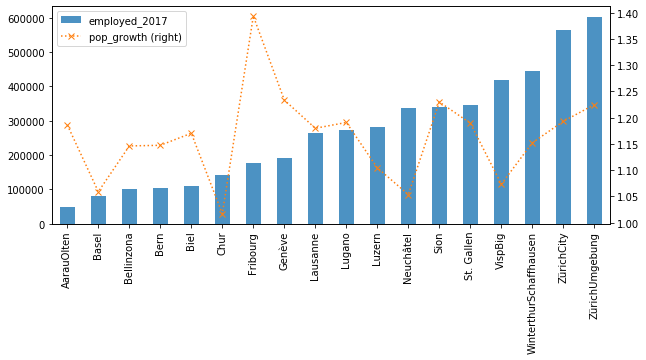

In [32]:
df = am_region_summary.loc[am_region_summary.index != "Unknown", 'employed_2017'].sort_values(ascending=True)
ax = df.plot.bar(figsize=(10, 4), alpha=0.8, legend=True)
xlim = ax.get_xlim()
ax = (am_region_summary['pop_growth']
      .loc[am_region_summary.index != "Unknown"]
      .plot(ax=ax, secondary_y=True, c='C01', rot=90, style=':x', legend=True)
     )

_ = ax.set_xlim(xlim)

In [33]:
print('Jobs per Employed person')
(am_region_summary['jobs_ch_2017'] / am_region_summary['employed_2017']).sort_values()

Jobs per Employed person


Fribourg                  0.832618
WinterthurSchaffhausen    0.845049
ZürichUmgebung            0.858074
Bellinzona                0.875388
Biel                      0.907733
AarauOlten                0.923482
Sion                      0.931060
St. Gallen                0.955202
Basel                     0.959175
Luzern                    0.973714
Chur                      0.975640
Lugano                    0.977250
Lausanne                  0.977318
VispBig                   0.992108
Neuchâtel                 1.016276
Genève                    1.064691
Bern                      1.127090
ZürichCity                1.302428
Unknown                        inf
dtype: float64

## Scaling up swiss jobs to match number of employed people

### Scaling Jobs (CH-only)

**Methdology:**
* The objectif is to get #jobs in 2040 to match #employed in 2040.
* First compute the number of missing jobs.
* We then distribute these jobs per AM-Regions propotinal to population growth (pop is the value we trust the most in the synpop).
* The jobs are then distributed to the businesses based with weighted probablity based on the number of jobs in 2017.

**Problem:**
* Appling the factor to the number of jobs will not work because a lot of companies have a small number of jobs. A 8% increase will not be noticed because of rounding effects. 

**Solution:** Jobs are not saled up but the new jobs are randomly assigned to a company. The companies are sampled with weights based on their number of jobs in 2017. 

In [34]:
businesses = businesses_ist.copy(deep=True)

In [35]:
tot_jobs_ist = businesses_ist['jobs_ch'].sum()
tot_employed = (persons['level_of_employment'] > 0).sum()
missing_jobs = tot_employed - tot_jobs_ist
print('Jobs in {}: {}'.format(YEAR_IST, tot_jobs_ist))
print('Employed people in {}: {}'.format(YEAR, tot_employed))
print('Jobs missing:  {}: {:.1f}%'.format(missing_jobs, missing_jobs / tot_jobs_ist * 100))

Jobs in 2017: 4827239
Employed people in 2040: 6205949
Jobs missing:  1378710: 28.6%


In [36]:
GLOBAL_JOB_GROWTH = (tot_employed / tot_jobs_ist)
GLOBAL_JOB_GROWTH

1.285610470084452

In [37]:
target_jobs_per_region = (am_region_summary['jobs_ch_2017'] * GLOBAL_JOB_GROWTH).round(0).astype(int)
missing_jobs_per_region = target_jobs_per_region - am_region_summary['jobs_ch_2017']  # jobs_17 is the basis 

In [38]:
%%time
new_jobs_list = []
for region, nb_jobs_missing in missing_jobs_per_region.items():
    # Weighted random draw of companies which will get new jobs 
    businesses_in_region = businesses_ist.query('arbeitsmarktregion == @region')
    new_jobs_list.append(businesses_in_region['business_id']
                         .sample(nb_jobs_missing, replace=True, weights=businesses_in_region['jobs_ch'])
                         .reset_index()
                         .groupby('business_id').count().iloc[:, 0]
                         .rename('new_jobs_ch')
                         )
new_jobs_ch = pd.concat(new_jobs_list)

Wall time: 1.82 s


In [39]:
# Add new jobs to the businesses
businesses = pd.merge(businesses, new_jobs_ch, how='left', left_on='business_id', right_index=True)
businesses['jobs_ch_{}'.format(YEAR_IST)] = businesses['jobs_ch']
businesses['new_jobs_ch'] = businesses['new_jobs_ch'].fillna(0).astype(int)
businesses['jobs_ch'] += businesses['new_jobs_ch']

In [40]:
# Adapting the fte in businesses where new jobs have been created
tot_fte = businesses_ist['fte_ch'].sum()
tot_loe = (persons['level_of_employment']).sum() / 100
missing_fte = tot_loe - tot_fte
avg_fte_per_new_job = (missing_fte / missing_jobs).round(2)
print('FTE given to new jobs: {}'.format(avg_fte_per_new_job))

# The trivial solution is to give all new jobs the same fte
businesses['fte_ch'] += avg_fte_per_new_job * businesses['new_jobs_ch']  # with new jobs come more fte too

FTE given to new jobs: 0.79


### Checking ...

#### New Jobs 

In [41]:
tot_jobs = businesses['jobs_ch'].sum()
print('In {}: total jobs = {} and total employed = {}'.format(YEAR, tot_jobs, tot_employed))

In 2040: total jobs = 6205947 and total employed = 6205949


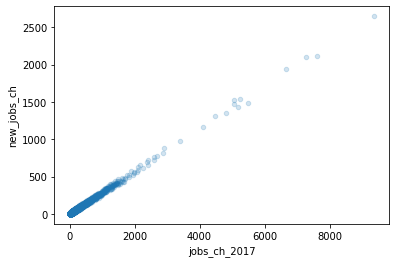

In [42]:
ax = businesses.plot.scatter(x='jobs_ch_2017', y='new_jobs_ch', alpha=0.2)

In [43]:
businesses_ist.columns

Index(['business_id', 'location_id', 'sector', 'legal_form', 'noga_code',
       'jobs_ch', 'fte_ch', 'jobs_cb', 'fte_cb', 'nr_of_cars', 'school_type',
       'xcoord', 'ycoord', 'bcoord_type', 'year_of_foundation', 'KT', 'N_KT',
       'ID_Gem', 'N_Gem', 'KT_full', 'ms_region', 'arbeitsmarktregion'],
      dtype='object')

In [44]:
businesses_ist.sort_values(['jobs_ch'], ascending=False).head(10)[['business_id', 'location_id', 'sector','jobs_ch',
       'fte_ch', 'jobs_cb', 'fte_cb', 'KT', 'N_KT', 'ID_Gem',
       'N_Gem', 'KT_full', 'ms_region', 'arbeitsmarktregion']]

,business_id,location_id,sector,jobs_ch,fte_ch,jobs_cb,fte_cb,KT,N_KT,ID_Gem,N_Gem,KT_full,ms_region,arbeitsmarktregion
141452,141453,35101029,non movers,9365,7412.94,14,11.08,2.0,BE,351.0,Bern,Bern / Berne,Bern,Bern
134787,134788,26101242,non movers,7618,6461.47,60,50.89,1.0,ZH,261.0,Zürich,Zürich,Zürich,ZürichCity
30499,30500,270101119,production,7283,6963.60,2251,2152.28,12.0,BS,2701.0,Basel,Basel-Stadt,Basel-Stadt,Basel
171423,171424,270101037,production,6651,6438.84,2055,1989.45,12.0,BS,2701.0,Basel,Basel-Stadt,Basel-Stadt,Basel
135481,135482,320301049,non movers,5501,4344.96,99,78.20,17.0,SG,3203.0,St. Gallen,St. Gallen,St.Gallen,St. Gallen
130409,130410,106101018,non movers,5258,4520.03,9,7.74,3.0,LU,1061.0,Luzern,Luzern,Luzern,Luzern
189563,189564,563501008,non movers,5194,4826.07,257,238.80,22.0,VD,5635.0,Ecublens (VD),Vaud,Lausanne,Lausanne
159330,159331,270101045,non movers,5075,3886.78,1568,1200.88,12.0,BS,2701.0,Basel,Basel-Stadt,Basel-Stadt,Basel
612143,612144,558601067,non movers,5061,4384.47,285,246.90,22.0,VD,5586.0,Lausanne,Vaud,Lausanne,Lausanne
391705,391706,6204018,wholesale,4808,4082.50,114,96.80,1.0,ZH,62.0,Kloten,Zürich,Glattal-Furttal,ZürichCity


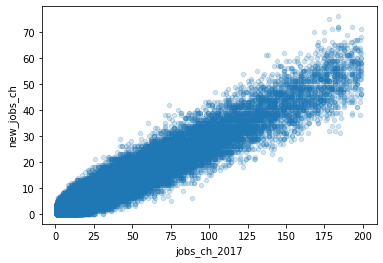

In [45]:
ax = businesses.query('jobs_ch_2017 < 200').plot.scatter(x='jobs_ch_2017', y='new_jobs_ch', alpha=0.2)

#### FTE

In [46]:
tot_fte = businesses['fte_ch'].sum().round(2)
print('In {}: total fte = {} and total loe = {}'.format(YEAR, tot_fte, tot_loe))

In 2040: total fte = 4844307.43 and total loe = 4840944.17


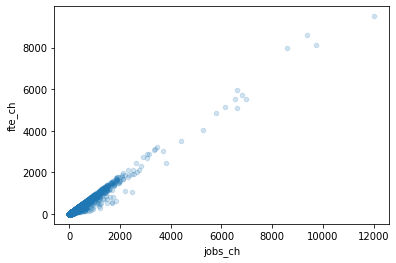

In [47]:
ax = businesses.query('new_jobs_ch > 0').plot.scatter(x='jobs_ch', y='fte_ch', alpha=0.2)

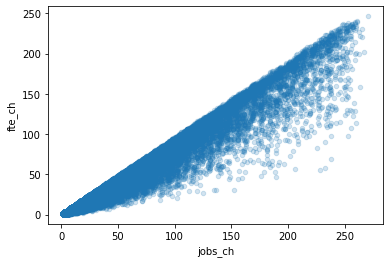

In [48]:
ax = businesses.query('(new_jobs_ch > 0) and (jobs_ch_2017 < 200)').plot.scatter(x='jobs_ch', y='fte_ch', alpha=0.2)

#### Commuter Flows 

In [49]:
commuter_factors_ist = (am_region_summary['jobs_ch_2017'] / am_region_summary['employed_2017']).sort_values().rename('ist')

In [50]:
commuter_factors = (businesses.groupby('arbeitsmarktregion')['jobs_ch'].sum() /am_region_summary['employed_2040']).rename('2040')

In [51]:
pd.concat([commuter_factors_ist, commuter_factors], axis=1).sort_values('ist')

,ist,2040
Fribourg,0.832618,0.696447
WinterthurSchaffhausen,0.845049,0.885679
ZürichUmgebung,0.858074,0.853429
Bellinzona,0.875388,0.865900
Biel,0.907733,0.907744
AarauOlten,0.923482,0.943398
Sion,0.931060,0.837617
St. Gallen,0.955202,0.965035
Basel,0.959175,1.082181
Luzern,0.973714,1.109308


In [52]:
# Scenario Year
persons['is_employed'] = persons['level_of_employment'] > 0
employed_per_am_region = persons.groupby('arbeitsmarktregion')['is_employed'].sum().astype(int).rename('employed_{}'.format(YEAR))
pop_per_am_region = persons.groupby('arbeitsmarktregion')['person_id'].count().rename('pop_{}'.format(YEAR))

# IST
persons_ist['is_employed'] = persons_ist['level_of_employment'] > 0
employed_per_am_region_ist = persons_ist.groupby('arbeitsmarktregion')['is_employed'].sum().astype(int).rename('employed_{}'.format(YEAR_IST))
pop_per_am_region_ist = persons_ist.groupby('arbeitsmarktregion')['person_id'].count().rename('pop_{}'.format(YEAR_IST))

## Cross Boundary Jobs

### Scaling CB Jobs 

* Initially, the cross-boundary jobs will get the same 8% increase as the swiss jobs 
* The likeness for a company to get a new cb job is proportional to it's number of cb jobs in 2017
* This may be refined in the future

In [53]:
target_cb_jobs = (businesses_ist['jobs_cb'].sum() * GLOBAL_JOB_GROWTH).round(0).astype(int)
missing_cb_jobs = target_cb_jobs - businesses_ist['jobs_cb'].sum()  # jobs_17 is the basis 

In [54]:
%%time
# Weighted random draw of companies which will get new jobs 
new_jobs_cb = (businesses_ist['business_id']
               .sample(missing_cb_jobs, replace=True, weights=businesses_ist['jobs_cb'])
               .reset_index()
               .groupby('business_id').count().iloc[:, 0]
               .rename('new_jobs_cb')
               )

Wall time: 114 ms


In [55]:
# Add new jobs to the businesses
businesses = pd.merge(businesses, new_jobs_cb, how='left', left_on='business_id', right_index=True)
businesses['new_jobs_cb'] = businesses['new_jobs_cb'].fillna(0).astype(int)
businesses['jobs_cb_{}'.format(YEAR_IST)] = businesses['jobs_cb']
businesses['jobs_cb'] += businesses['new_jobs_cb']

In [56]:
# Using the same average fte per new jobs as for swiss jobs since no data
print('FTE given to new jobs: {}'.format(avg_fte_per_new_job))

# The trivial solution is to give all new jobs the same fte
businesses['fte_cb'] += avg_fte_per_new_job * businesses['new_jobs_cb'] 

FTE given to new jobs: 0.79


### Checking

In [57]:
tot_jobs_cb_ist = businesses_ist['jobs_cb'].sum()
print('In {}: total jobs-cb = {}'.format(YEAR_IST, tot_jobs_cb_ist))
tot_jobs_cb = businesses['jobs_cb'].sum()
print('In {}: total jobs-cb = {}'.format(YEAR, tot_jobs_cb))
print('CB-Jobs increase: {:.0f} %'.format(((tot_jobs_cb - tot_jobs_cb_ist) / tot_jobs_cb_ist) * 100))

In 2017: total jobs-cb = 293096
In 2040: total jobs-cb = 376807
CB-Jobs increase: 29 %


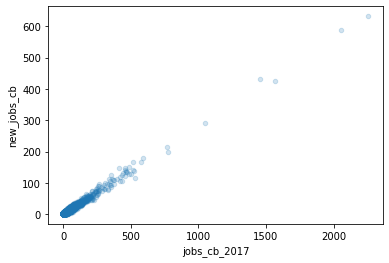

In [58]:
ax = businesses.query('new_jobs_cb > 0').plot.scatter(x='jobs_cb_2017', y='new_jobs_cb', alpha=0.2)

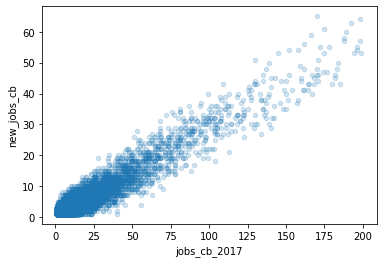

In [59]:
ax = businesses.query('(new_jobs_cb > 0) and (jobs_cb_2017 < 200)').plot.scatter(x='jobs_cb_2017', y='new_jobs_cb', alpha=0.2)

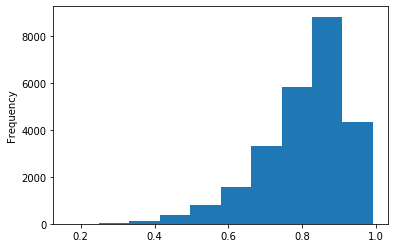

In [60]:
ax = (businesses.query('new_jobs_cb > 0')['fte_cb'] / businesses.query('new_jobs_cb > 0')['jobs_cb']).plot.hist()

## Saving Results 

In [61]:
%%time
if SAVE_OUTPUTS:
    results_file = os.path.join(OUTPUT_DIR, 'fixed_businesses.pickle.gzip')
    businesses[businesses_ist.columns].to_pickle(results_file, compression='gzip')

Wall time: 1min 3s


## Export Notebook to HTML

In [62]:
### Write notebook to a html file
!jupyter nbconvert --to html 10_Businesses_and_Jobs.ipynb

[NbConvertApp] Converting notebook 10_Businesses_and_Jobs.ipynb to html
[NbConvertApp] Writing 636183 bytes to 10_Businesses_and_Jobs.html
